In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy.stats import trim_mean
import math
from pandas.api.types import ( is_numeric_dtype, is_categorical_dtype, is_object_dtype, is_datetime64_any_dtype )
from default_risk.scripts.variable_profiling import eda_per_table_printing_results
from default_risk.scripts.variable_profiling import eda_per_table_persisting_result_html
from default_risk.scripts.variable_profiling import create_files_nulls_per_colmun
import default_risk.config as cfg


application_train_df = pd.read_csv(cfg.APPLICATION_TRAIN)

with open(cfg.SCHEMA_JSON, "r") as f:
    schema = json.load(f)

In [6]:
#files for the data dictionary
create_files_nulls_per_colmun(application_train_df,"application_train")

In [3]:
feature_cols = [c for c in application_train_df.columns if c not in ["SK_ID_CURR", "TARGET"]]
X = application_train_df[feature_cols]
y = application_train_df["TARGET"]

In [4]:
eda_per_table_persisting_result_html(X,schema,"application",False)

In [2]:
eda_per_table_persisting_result_html(application_train_df,schema,"application",True)

In [6]:

#now we will explore the hypothesis of train one model per type of contract. Starting for how viable is with the data available

print(application_train_df["NAME_CONTRACT_TYPE"].value_counts(normalize=True) * 100)
print(application_train_df.groupby("NAME_CONTRACT_TYPE")["TARGET"].mean() * 100)

#Considering the volume of the minoritary class (less than 10%) and their event ratio (5%) seems not ideal have to separate the models.

NAME_CONTRACT_TYPE
Cash loans         90.478715
Revolving loans     9.521285
Name: proportion, dtype: float64
NAME_CONTRACT_TYPE
Cash loans         8.345913
Revolving loans    5.478329
Name: TARGET, dtype: float64


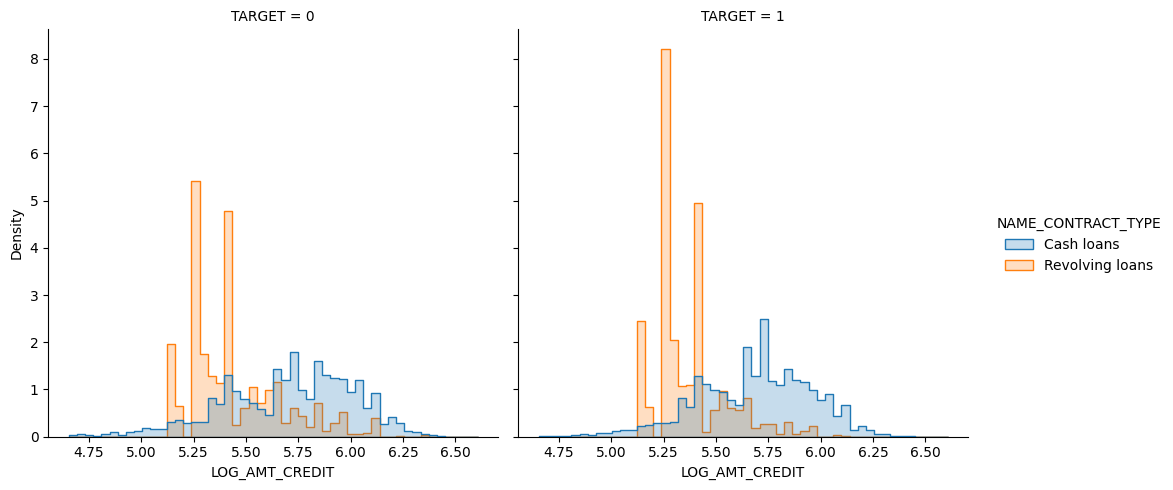

In [7]:
#here i want to check if the main variables that describes the loan change their distribution and trending between the type of contract,
#and also see how much change in the case of default. 

application_train_df["LOG_AMT_CREDIT"]= np.log10(application_train_df["AMT_CREDIT"])

g = sns.displot(
    data=application_train_df,
    x="LOG_AMT_CREDIT",
    hue="NAME_CONTRACT_TYPE",
    bins=50,
    element="step",
    stat="density",
    col="TARGET",
    common_norm=False
)

for ax in g.axes.flat:
    ax.ticklabel_format(style='plain', axis='x')
    ax.ticklabel_format(style='plain', axis='y')

#default and the mont of the loan have negative correlation. In both type of contracts. That's a good proof about the similar behaivor between clases 
#and seems unnecesary split and train 2 diferent models.

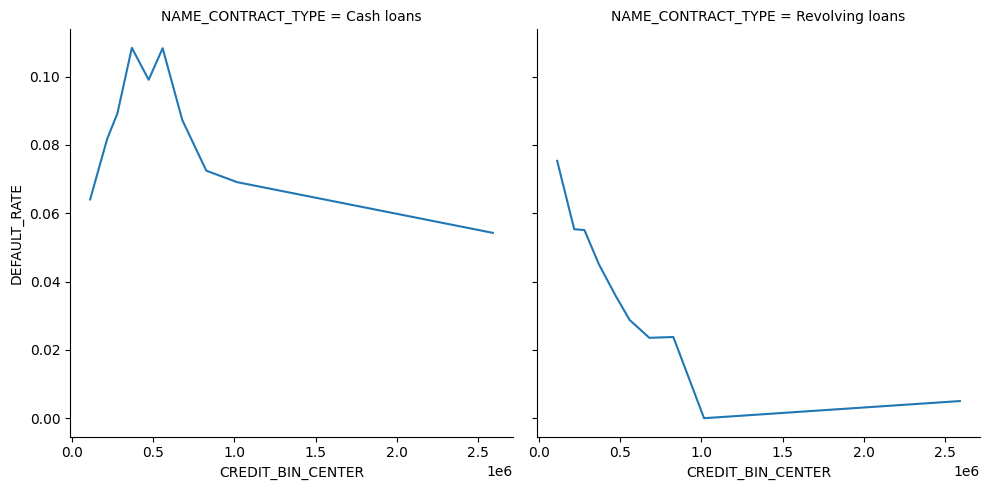

In [8]:
bins= np.arange(0,application_train_df["AMT_CREDIT"].max() + 100000, 100000)
application_train_df["BINED_AMT_CREDIT"]=  pd.qcut(application_train_df["AMT_CREDIT"],10)
application_train_df_groupBy_bins = application_train_df.groupby(["BINED_AMT_CREDIT","NAME_CONTRACT_TYPE"],observed=True)["TARGET"].agg(
    DEFAULT_RATE="mean",
    COUNT="size").reset_index()
application_train_df_groupBy_bins["CREDIT_BIN_CENTER"] = application_train_df_groupBy_bins["BINED_AMT_CREDIT"].apply(lambda x: x.mid)


gr=sns.relplot(data=application_train_df_groupBy_bins,x="CREDIT_BIN_CENTER",y="DEFAULT_RATE",kind="line",col="NAME_CONTRACT_TYPE")

In [5]:
documents_flags_names= ["FLAG_DOCUMENT_"+ str(i) for i in range (2,22)]
print(documents_flags_names)

['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']


"""About the idea of creating 2 different models for each type of contract: 

The amount of data and events is something to consider.
revolving loans represent 9.5% of observations and have a default ratio of 5%.
Therefore, train separate models significantly reduce the amount of total data and default events.

the analysis of the deciles of amount of credit and their respective default rate show similar overall trends for both contracts types, but have noticiable diferences in some segments.
For linear models this would require some features to model the interaction but in case of using tree based models the feature CONTRACT_TYPE 
seems enough

In conclusion, this preliminary analisis show there is no strong evidence supporting the need for two separate models. Even so, this hypothesis
will be tested formally later comparing model performance.
"""